In [4]:
import numpy as np
import jax
import jax.numpy as jnp
import diffrax as dfrx
import json
import pandas as pd
import arviz as az
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import Divider, Size

# import models
import sys
sys.path.insert(0, '../odes')
sys.path.insert(0, '../global_sensitivity_analysis')
import ampk_MA_double_mech_diffrax as model
from gsa_utils import *

jax.config.update('jax_enable_x64', True)

# %matplotlib inline
plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True
cols = sns.color_palette(palette='colorblind', n_colors=3)
print(cols.as_hex())

['#0173b2', '#de8f05', '#029e73']


In [2]:
# load a bunch of sampling data
cyto_prior = az.from_netcdf('./MA_double_mech/cyto_prior_predictive.nc')
lyso_prior = az.from_netcdf('./MA_double_mech/lyso_prior_predictive.nc')
mito_prior = az.from_netcdf('./MA_double_mech/mito_prior_predictive.nc')

cyto_post = az.from_netcdf('./MA_double_mech/cyto_posterior.nc')
lyso_post = az.from_netcdf('./MA_double_mech/lyso_posterior.nc')
mito_post = az.from_netcdf('./MA_double_mech/mito_posterior.nc')

cyto_post_pred = az.from_netcdf('./MA_double_mech/cyto_posterior_predictive.nc')
lyso_post_pred = az.from_netcdf('./MA_double_mech/lyso_posterior_predictive.nc')
mito_post_pred = az.from_netcdf('./MA_double_mech/mito_posterior_predictive.nc')

In [5]:
cyto_post

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [4]:
# load microscopy data
cyto = np.load('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz')
cyto_times = 60*cyto['times']
zero_idx = int(np.where(cyto_times==0.0)[0]) # we only want values after the 2-DG stimulus
cyto_times = cyto_times[zero_idx:]
cyto_mean = cyto['mean'][zero_idx:]
lyso = np.load('../../../Schmitt_et_al_2022_data/fig_2b_lyso.npz')
lyso_times = 60*lyso['times']
zero_idx = int(np.where(lyso_times==0.0)[0]) # we only want values after the 2-DG stimulus
lyso_times = lyso_times[zero_idx:]
lyso_mean = lyso['mean'][zero_idx:]
mito = np.load('../../../Schmitt_et_al_2022_data/fig_2c_mito.npz')
mito_times = 60*mito['times']
zero_idx = int(np.where(mito_times==0.0)[0]) # we only want values after the 2-DG stimulus
mito_times = mito_times[zero_idx:]
mito_mean = mito['mean'][zero_idx:]

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_7582/4252740078.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  zero_idx = int(np.where(cyto_times==0.0)[0]) # we only want values after the 2-DG stimulus
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_7582/4252740078.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  zero_idx = int(np.where(lyso_times==0.0)[0]) # we only want values after the 2-DG stimulus
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_7582/4252740078.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract

In [141]:
model_info_json = '../global_sensitivity_analysis/MA_double.json'
nominals_file = '../global_sensitivity_analysis/nominal_params_MA.csv'


############################################
# SETUP DIFFRAX solver
############################################
# states and initial conditions
with open(model_info_json, 'r') as file:
        model_data = json.load(file)

# unpack loaded model data dictionary
state_names = model_data['state_names']
ampkar_states = model_data['ampkar_states']
pampkar_states = model_data['pampkar_states']
n_states = len(state_names)
y0_states_to_set = model_data['y0']['set_states']
y0_vals_to_set = model_data['y0']['set_ics']

# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]
ampkar_idx = state_names.index('AMPKAR')
pampkar_idx = state_names.index('pAMPKAR')

################################################
# Nominal parameters
################################################
nominals_file = pd.read_csv(nominals_file)
nominals = {}
for key, val in zip(nominals_file['parameter'].to_list(),  nominals_file['value'].to_list()):
     nominals[key] = val

# fix AMPKAR_0 because it is not identifiable and it will be tricky to set in the model
AMPKAR_0 = nominals['AMPKAR_0']

# fixed parameters
kOffCaMKK =  nominals['kOffCaMKK']
kPhosCaMKK = nominals['kPhosCaMKK']
kOffLKB1 =   nominals['kOffLKB1']
kPhosLKB1 =  nominals['kPhosLKB1']
kOffPP =     nominals['kOffPP']
kDephosPP =  nominals['kDephosPP']
kOffPP1 =   nominals['kOffPP1']

# Set initial conditions
y0 = np.zeros(n_states)
for state, val in zip(y0_states_to_set, y0_vals_to_set):
    y0[state_names.index(state)] = val
y0[ampkar_idx] = AMPKAR_0
# random seed for reproducibility
seed = np.random.seed(seed=2048)

################################################
#                   Model RHS                  #
################################################
# metabolism_params
metab_parms_basal = {'kGly': 0.5,'kHydro':0.1,
                     'VforAK': 14.66, 'KeqAK': 2.21, 'kmm': 0.32, 'kmd': 0.35, 'kmt': 0.27,
                     'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}
metab_parms_stress = {'kGly': 0.005,'kHydro':0.1,
                      'VforAK': 14.66, 'KeqAK': 2.21, 'kmm': 0.32, 'kmd': 0.35, 'kmt': 0.27,
                     'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}

rhs = model.vector_field(**metab_parms_basal)
rhs_stress = model.vector_field(**metab_parms_stress)
rhs = dfrx.ODETerm(rhs)
rhs_stress = dfrx.ODETerm(rhs_stress)

################################################
# Jax functions for the ODE solution and the gradient
################################################
t0 = 0.0
solver=dfrx.Kvaerno5()
event_rtol = 1e-8
event_atol = 1e-8
event = dfrx.SteadyStateEvent(event_rtol, event_atol)
stepsize_controller = dfrx.PIDController(rtol=1e-8, atol=1e-8)

@jax.jit
def solve_model(KdAMP, KdADP, KdATP, kOffAMPK, kPhosAMPK, kDephosPP1, times):
    saveat=dfrx.SaveAt(ts=times)
    t1 = times[-1]
    args = compute_MA_params([KdAMP, KdADP, KdATP, kOffCaMKK, kPhosCaMKK, kOffLKB1, kPhosLKB1, kOffPP,
               kDephosPP, kOffAMPK, kPhosAMPK, kOffPP1, kDephosPP1, AMPKAR_0]) # tuple to pass to the solver!
    # first run the system to the estimates basal steady state
    # this gives us the initial condition for the stress response
    sol_basal = dfrx.diffeqsolve(
            rhs, solver, t0=t0, t1=1e5, dt0=1e-8,
            y0=y0, # known initial conditions!, we can change later
            stepsize_controller=stepsize_controller,
            discrete_terminating_event=event,
            args=args, throw=False,
        )
    print(sol_basal.ys[-1,:])
    # now we purturb the system by changing the glycolysis paramter
    # and solve the model at the experimental time points
    sol_stress = dfrx.diffeqsolve(
            rhs_stress, solver, t0=t0, t1=t1, dt0=1e-8,
            y0=sol_basal.ys[-1,:], # known initial conditions!, we can change later
            saveat=saveat, stepsize_controller=stepsize_controller,
            args=args, 
            throw=True,
        )
    
    # now compute the QOI which should match the experimental data
    AMPKAR_tot_basal = np.sum(sol_basal.ys[:,ampkar_idxs], axis=1)
    AMPKAR_tot_stress = np.sum(sol_stress.ys[:,ampkar_idxs], axis=1)
    pAMPKAR_basal = np.sum(sol_basal.ys[:,pampkar_idxs], axis=1)
    pAMPKAR_stress = np.sum(sol_stress.ys[:,pampkar_idxs], axis=1)
    qoi = (pAMPKAR_stress/AMPKAR_tot_stress)-(pAMPKAR_basal[-1]/AMPKAR_tot_basal[-1])
    
    return qoi

def plot_pred_check(sols, times, ax, alpha, color):
    nens = sols.shape[0]
    names = ['run'+str(i) for i in range(nens)]
    sol_dict = {'run':{}, 'timepoint':{}, 'qoi':{},}
    idxs = np.linspace(0, (nens*times.shape[0]-1), nens*times.shape[0])
    cnt = 0
    for i in range(nens):
        for j in range(times.shape[0]):
            sol_dict['run'][int(idxs[cnt])] = names[i]
            sol_dict['timepoint'][int(idxs[cnt])] = times[j]
            sol_dict['qoi'][int(idxs[cnt])] = sols[i,j]
            cnt += 1

    sol_df=pd.DataFrame.from_dict(sol_dict,)
    sns.lineplot(data=sol_df,
                x='timepoint',
                y='qoi',
                color=color,
                legend=False,
                errorbar=('pi', 95), # percentile interval form 2.5th to 97.5th
                ax=ax,
                alpha=alpha)

In [142]:
# generate prior and posterior samples
cyto_prior_samples = np.vstack([cyto_prior.prior.KdAMP.to_numpy(),
            cyto_prior.prior.KdADP.to_numpy(),
            cyto_prior.prior.KdATP.to_numpy(),
            cyto_prior.prior.kOffAMPK.to_numpy(),
            cyto_prior.prior.kPhosAMPK.to_numpy(),
            cyto_prior.prior.kDephosPP1.to_numpy()])

lyso_prior_samples = np.vstack([lyso_prior.prior.KdAMP.to_numpy(),
            lyso_prior.prior.KdADP.to_numpy(),
            lyso_prior.prior.KdATP.to_numpy(),
            lyso_prior.prior.kOffAMPK.to_numpy(),
            lyso_prior.prior.kPhosAMPK.to_numpy(),
            lyso_prior.prior.kDephosPP1.to_numpy()])

mito_prior_samples = np.vstack([mito_prior.prior.KdAMP.to_numpy(),
            mito_prior.prior.KdADP.to_numpy(),
            mito_prior.prior.KdATP.to_numpy(),
            mito_prior.prior.kOffAMPK.to_numpy(),
            mito_prior.prior.kPhosAMPK.to_numpy(),
            mito_prior.prior.kDephosPP1.to_numpy()])

cyto_post_samples = np.vstack([cyto_post.posterior.KdAMP.to_numpy(),
            cyto_post.posterior.KdADP.to_numpy(),
            cyto_post.posterior.KdATP.to_numpy(),
            cyto_post.posterior.kOffAMPK.to_numpy(),
            cyto_post.posterior.kPhosAMPK.to_numpy(),
            cyto_post.posterior.kDephosPP1.to_numpy()])

lyso_post_samples = np.vstack([lyso_post.posterior.KdAMP.to_numpy(),
            lyso_post.posterior.KdADP.to_numpy(),
            lyso_post.posterior.KdATP.to_numpy(),
            lyso_post.posterior.kOffAMPK.to_numpy(),
            lyso_post.posterior.kPhosAMPK.to_numpy(),
            lyso_post.posterior.kDephosPP1.to_numpy()])

mito_post_samples = np.vstack([mito_post.posterior.KdAMP.to_numpy(),
            mito_post.posterior.KdADP.to_numpy(),
            mito_post.posterior.KdATP.to_numpy(),
            mito_post.posterior.kOffAMPK.to_numpy(),
            mito_post.posterior.kPhosAMPK.to_numpy(),
            mito_post.posterior.kDephosPP1.to_numpy()])

nens = 200
param = cyto_prior_samples[:,0]
solve_model(param[0], param[1], param[2], param[3], param[4], param[5], cyto_times)
cyto_prior_sols = np.zeros((nens, cyto_times.shape[0]))
idxs = np.random.randint(0, cyto_prior_samples.shape[1], nens)
for idx, i in zip(idxs, range(nens)):
    param = cyto_prior_samples[:,idx]
    cyto_prior_sols[i] = solve_model(param[0], param[1], param[2], param[3], param[4], param[5], cyto_times)

Traced<ShapedArray(float64[53], weak_type=True)>with<DynamicJaxprTrace(level=1/0)>


In [6]:
param = lyso_prior_samples[:,0]
solve_model(param[0], param[1], param[2], param[3], param[4], param[5], lyso_times)
lyso_prior_sols = np.zeros((nens, lyso_times.shape[0]))
idxs = np.random.randint(0, lyso_prior_samples.shape[1], nens)
for idx, i in zip(idxs, range(nens)):
    param = lyso_prior_samples[:,idx]
    lyso_prior_sols[i] = solve_model(param[0], param[1], param[2], param[3], param[4], param[5], lyso_times)

In [7]:
nens = 200
param = mito_prior_samples[:,0]
solve_model(param[0], param[1], param[2], param[3], param[4], param[5], mito_times)
mito_prior_sols = np.zeros((nens, mito_times.shape[0]))
idxs = np.random.randint(0, mito_prior_samples.shape[1], nens)
for idx, i in zip(idxs, range(nens)):
    param = mito_prior_samples[:,idx]
    mito_prior_sols[i] = solve_model(param[0], param[1], param[2], param[3], param[4], param[5], mito_times)


Traced<ShapedArray(float64[53], weak_type=True)>with<DynamicJaxprTrace(level=1/0)>


In [8]:
param = cyto_prior_samples[:,0]
solve_model(param[0], param[1], param[2], param[3], param[4], param[5], cyto_times)
cyto_post_sols = np.zeros((nens, cyto_times.shape[0]))
idxs = np.random.randint(0, cyto_post_samples.shape[1], nens)
for idx, i in zip(idxs, range(nens)):
    param = cyto_post_samples[:,idx]
    cyto_post_sols[i] = solve_model(param[0], param[1], param[2], param[3], param[4], param[5], cyto_times)

In [9]:
param = lyso_prior_samples[:,0]
solve_model(param[0], param[1], param[2], param[3], param[4], param[5], lyso_times)
lyso_post_sols = np.zeros((nens, lyso_times.shape[0]))
idxs = np.random.randint(0, lyso_post_samples.shape[1], nens)
for idx, i in zip(idxs, range(nens)):
    param = lyso_post_samples[:,idx]
    lyso_post_sols[i] = solve_model(param[0], param[1], param[2], param[3], param[4], param[5], lyso_times)

In [10]:
param = mito_prior_samples[:,0]
solve_model(param[0], param[1], param[2], param[3], param[4], param[5], mito_times)
mito_post_sols = np.zeros((nens, mito_times.shape[0]))
idxs = np.random.randint(0, mito_post_samples.shape[1], nens)
for idx, i in zip(idxs, range(nens)):
    param = mito_post_samples[:,idx]
    mito_post_sols[i] = solve_model(param[0], param[1], param[2], param[3], param[4], param[5], mito_times)

Text(0.5, 0.98, 'Mitochondria Parameters')

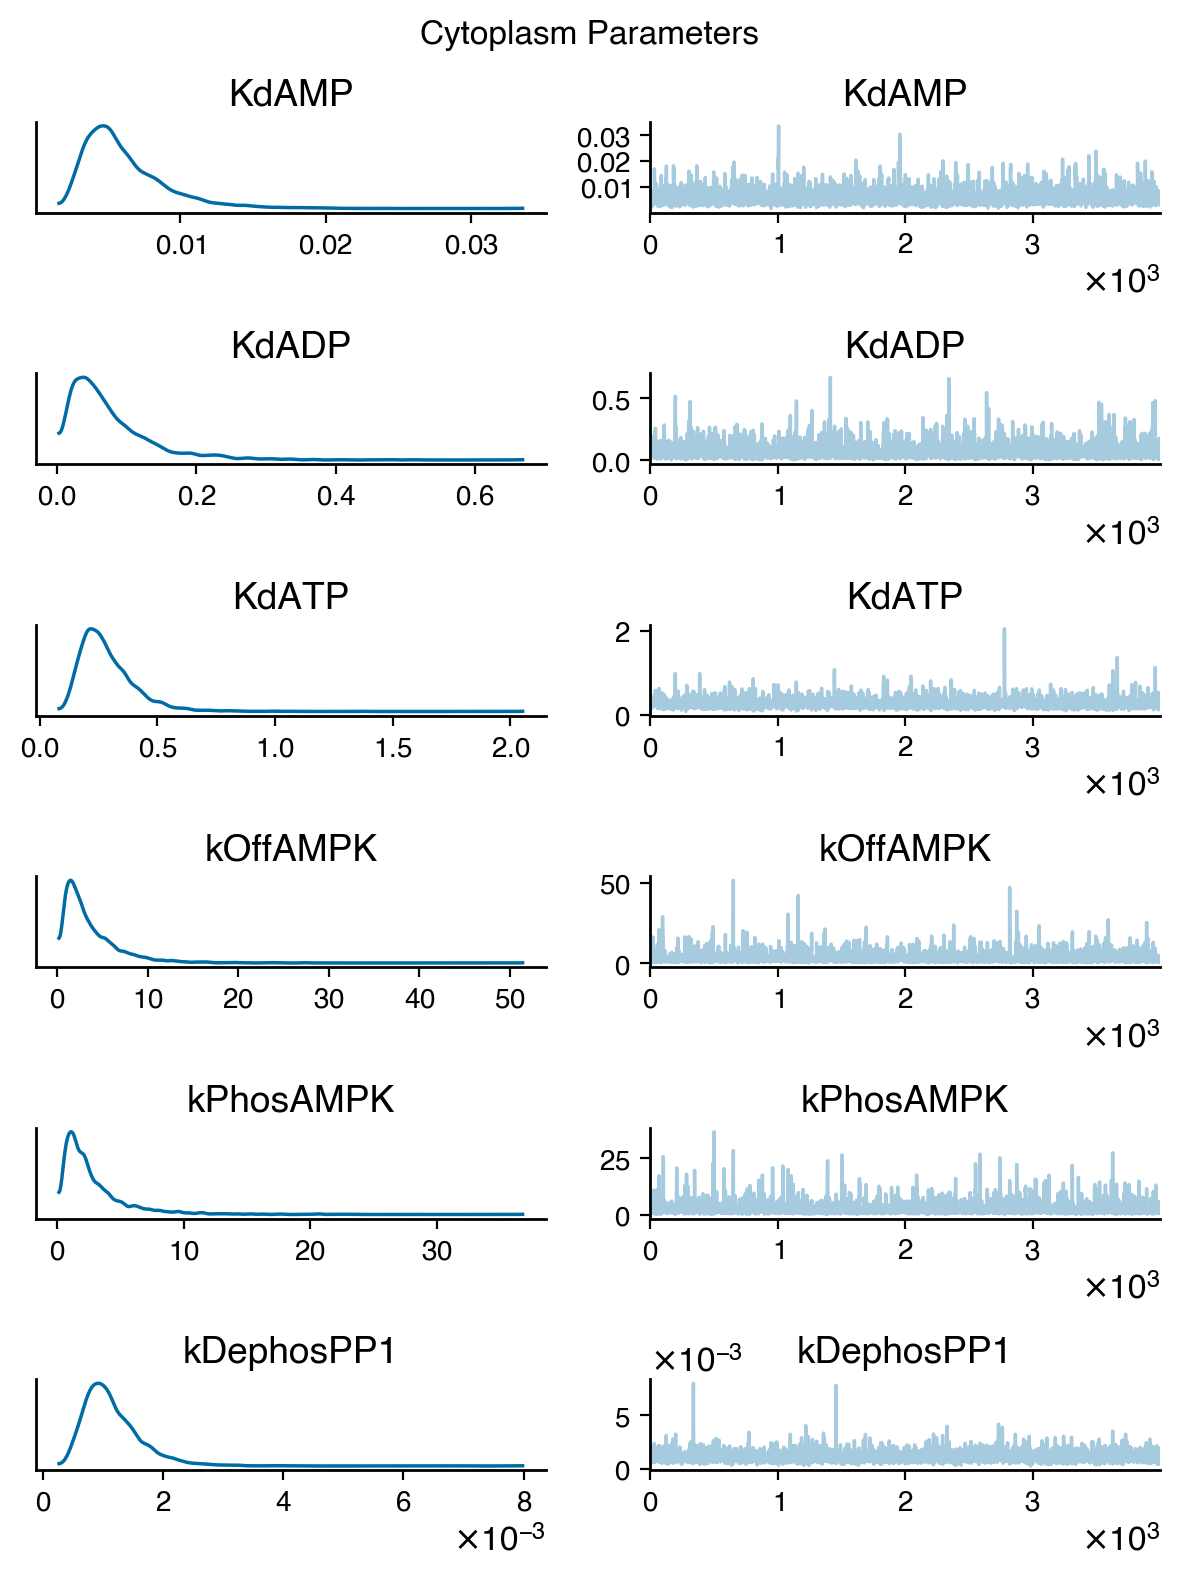

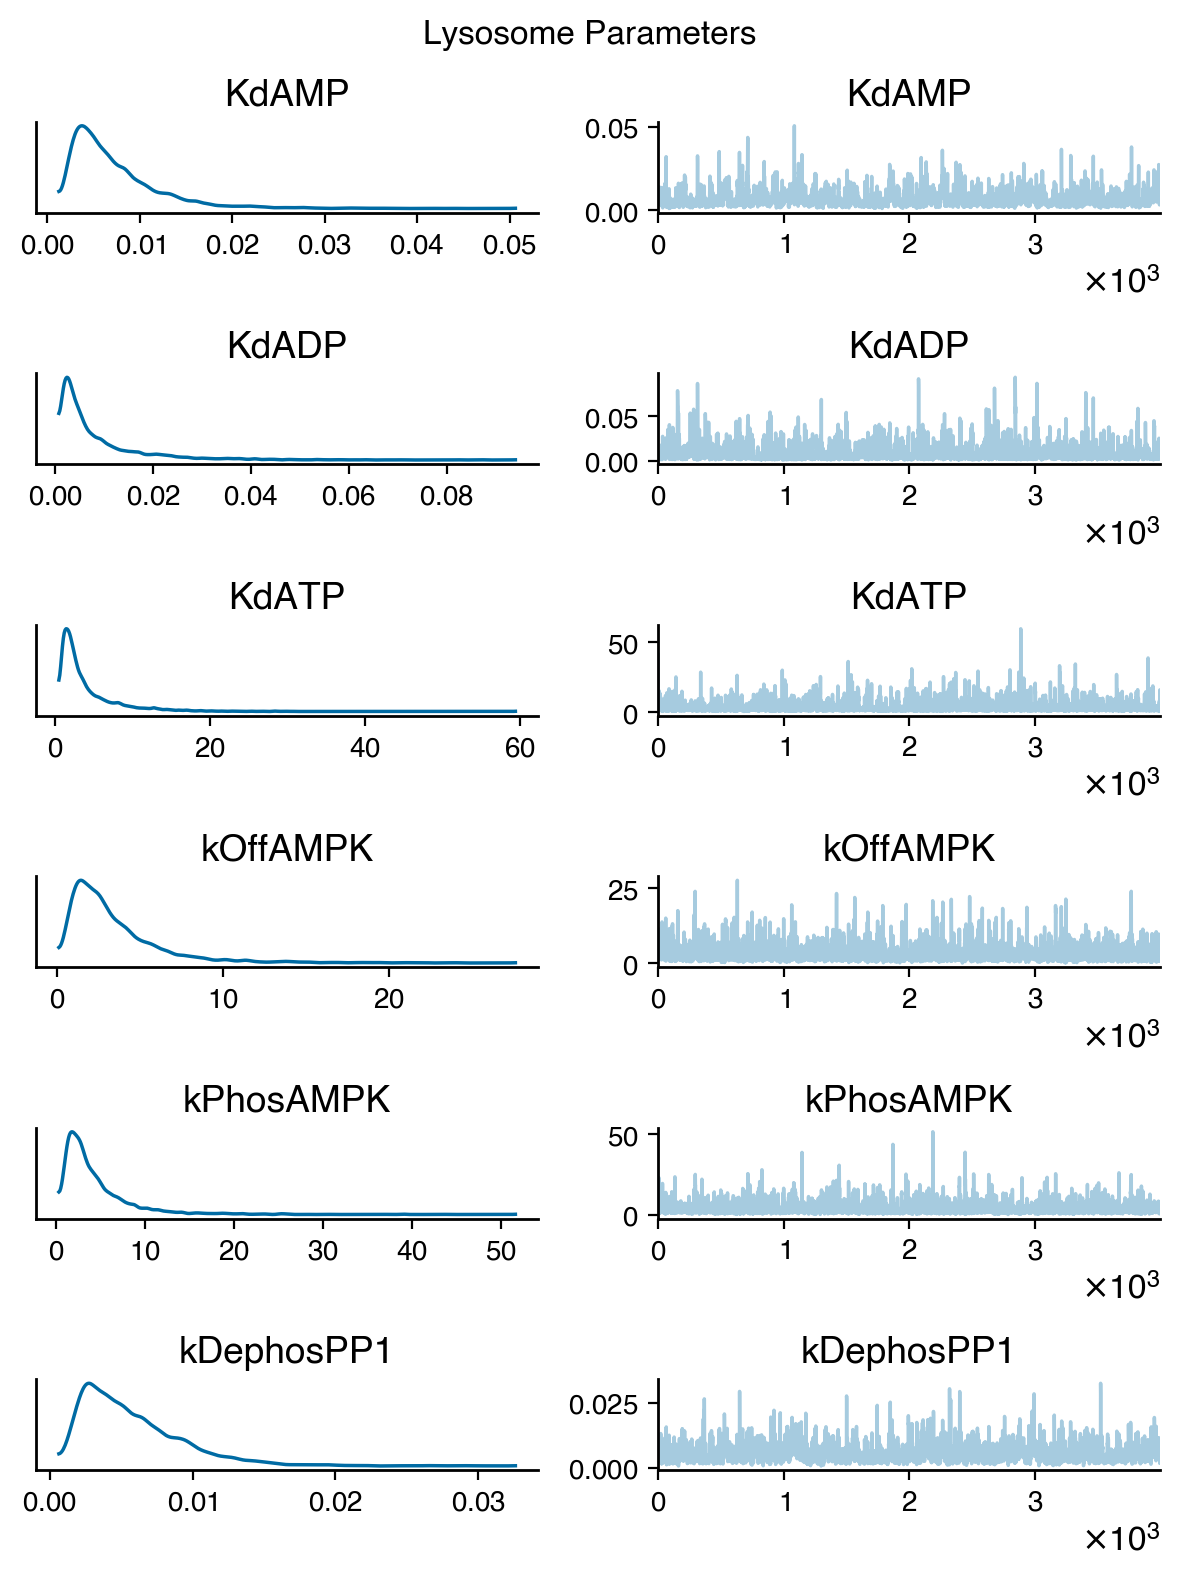

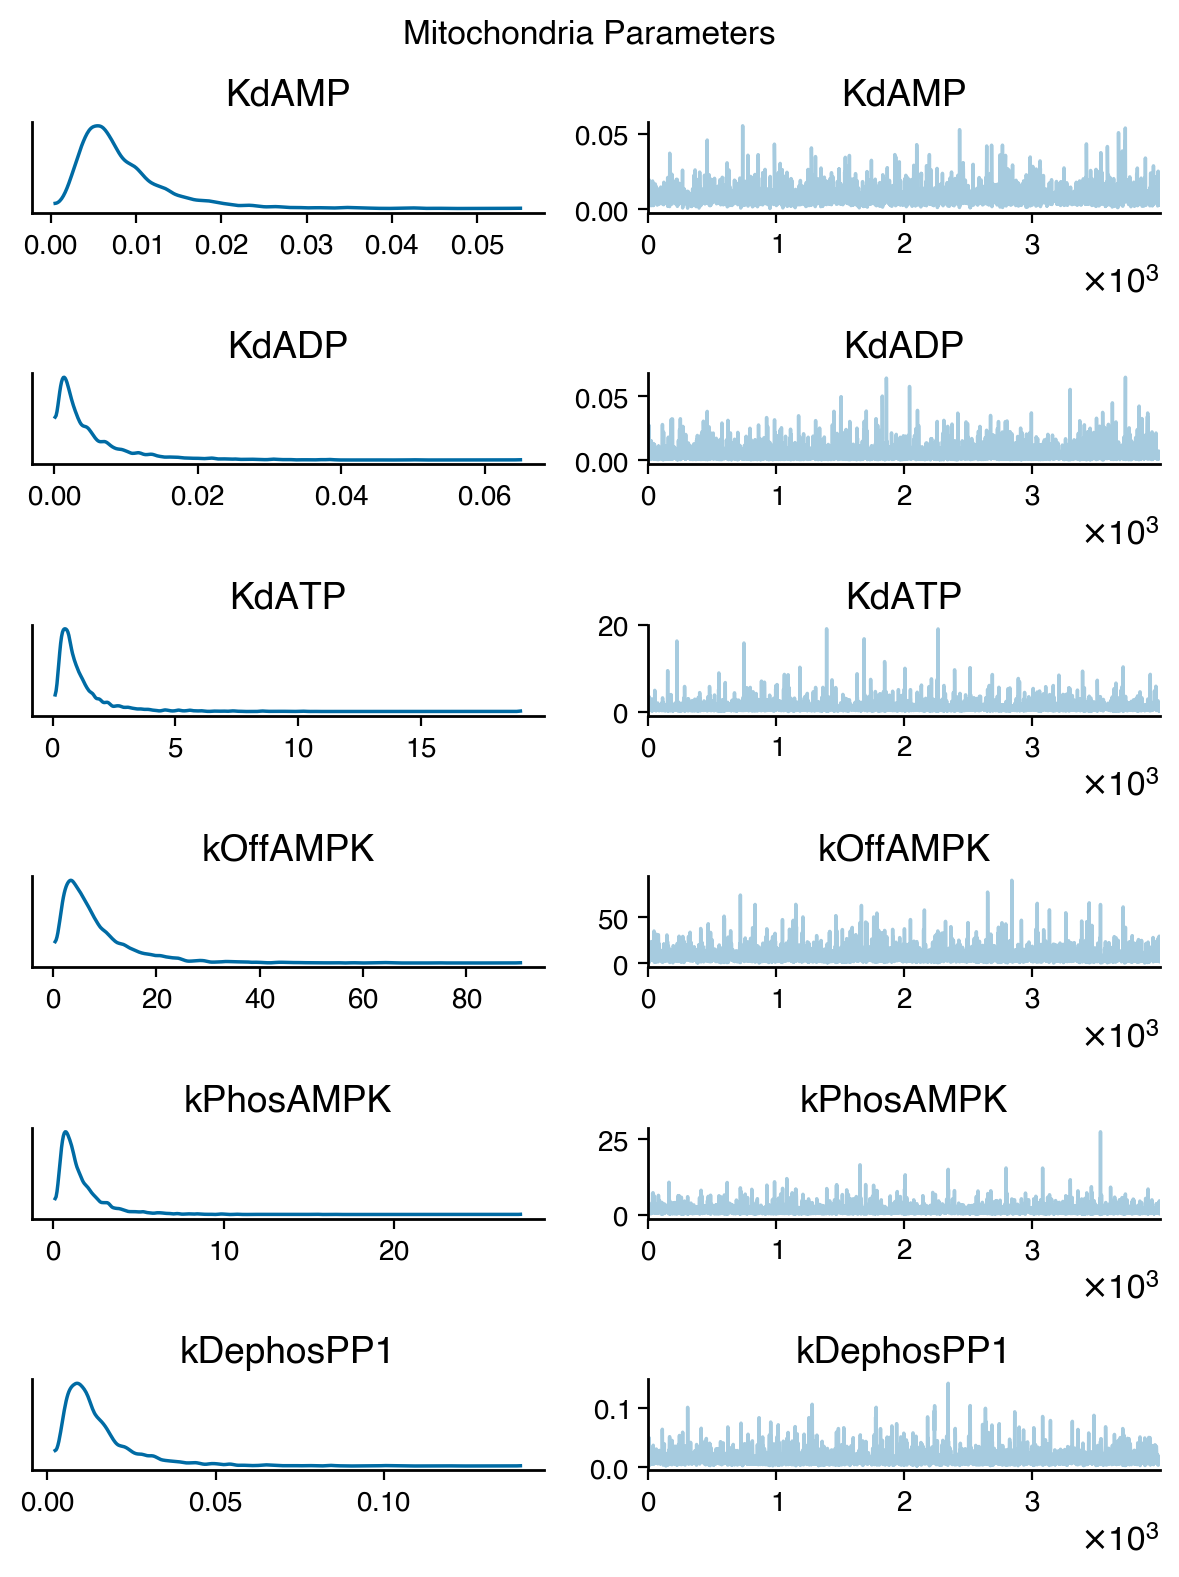

In [11]:
# plot traces
fig_cyto, axs_cyto = plt.subplots(6, 2, figsize=(6, 8))
az.plot_trace(cyto_post, axes=axs_cyto)
fig_cyto.suptitle('Cytoplasm Parameters')

fig_lyso, axs_lyso = plt.subplots(6, 2, figsize=(6, 8))
az.plot_trace(lyso_post, axes=axs_lyso)
fig_lyso.suptitle('Lysosome Parameters')

fig_mito, axs_mito = plt.subplots(6, 2, figsize=(6, 8))
az.plot_trace(mito_post, axes=axs_mito)
fig_mito.suptitle('Mitochondria Parameters')

In [181]:
# cols = ['dullblue', 'grey', 'orange']

Axes(0.125,0.11;0.775x0.77)


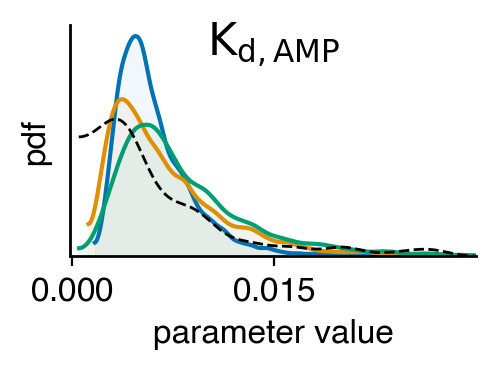

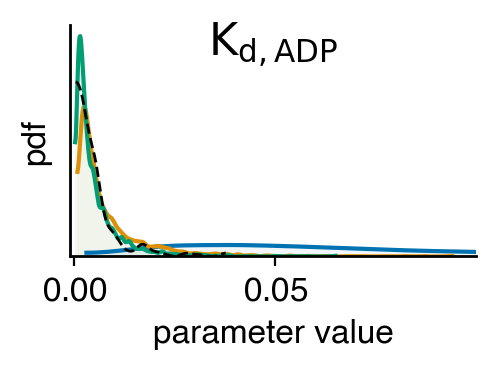

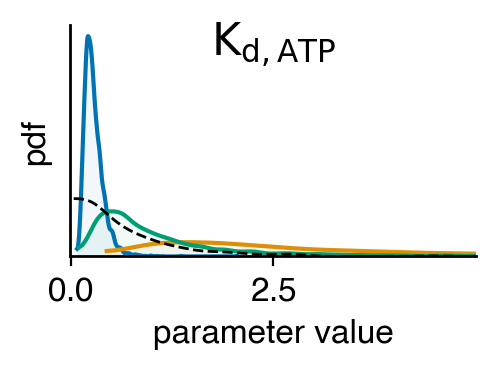

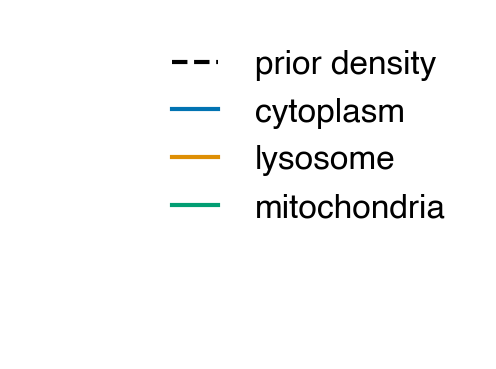

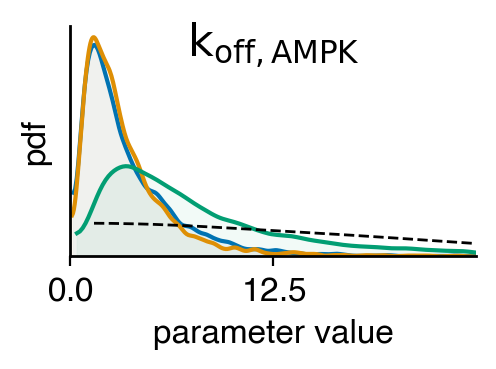

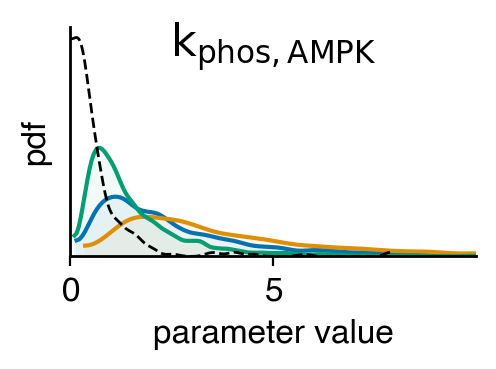

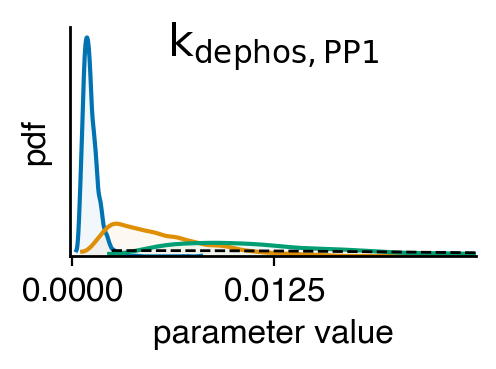

In [185]:
def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

def fixed_size_axis(fig, a,b,c,d):
    h = [Size.Fixed(a), Size.Fixed(b)]
    v = [Size.Fixed(c), Size.Fixed(d)]
    
    divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
    # The width and height of the rectangle are ignored.
    
    return fig.add_axes(divider.get_position(),
                      axes_locator=divider.new_locator(nx=1, ny=1))

w=2.0
h=1.5
# KdAMP
fig, ax = plt.subplots(figsize=(w,h))
# ax = fixed_size_axis(fig, 0.5 ,0.5 ,2, 1.5)
print(ax)
az.plot_dist(cyto_post.posterior.KdAMP, kind='kde', ax=ax, color=cols[0], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_post.posterior.KdAMP, kind='kde', ax=ax, color=cols[1], fill_kwargs={'alpha': 0.05})
az.plot_dist(mito_post.posterior.KdAMP, kind='kde', ax=ax, color=cols[2], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_prior.prior.KdAMP, kind='kde', ax=ax, color='k', fill_kwargs={'alpha': 0}, 
                plot_kwargs={'linestyle': '--', 'linewidth': 1.0})
ax.set_xlim([-0.0001, 0.03])
ylim = ax.get_ylim()
ax.set_ylim([0.0, ylim[1]])
ax.set_title(r'$K_{d,AMP}$', y=0.8)
ax.set_xlabel('parameter value')
ax.set_ylabel('pdf', labelpad=7)
ax.set_yticks([])
ax.set_xticks([0.0, 0.015])
set_size(w,h,ax=ax)
fig.savefig('../../../figures/MA_double_mech/KdAMP_posterior.pdf')

# KdADP
fig, ax = plt.subplots(figsize=(w,h))
az.plot_dist(cyto_post.posterior.KdADP, kind='kde', ax=ax, color=cols[0], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_post.posterior.KdADP, kind='kde', ax=ax, color=cols[1], fill_kwargs={'alpha': 0.05})
az.plot_dist(mito_post.posterior.KdADP, kind='kde', ax=ax, color=cols[2], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_prior.prior.KdADP, kind='kde', ax=ax, color='k', fill_kwargs={'alpha': 0}, 
                plot_kwargs={'linestyle': '--', 'linewidth': 1.0})
ax.set_xlim([-0.001, 0.1])
ylim = ax.get_ylim()
ax.set_ylim([0.0, ylim[1]])
ax.set_title(r'$K_{d,ADP}$', y=0.8)
ax.set_xlabel('parameter value')
ax.set_ylabel('pdf', labelpad=7)
ax.set_yticks([])
ax.set_xticks([0.0, 0.05])
set_size(w,h,ax=ax)
fig.savefig('../../../figures/MA_double_mech/KdADP_posterior.pdf')

# KdATP
fig, ax = plt.subplots(figsize=(w,h))
az.plot_dist(cyto_post.posterior.KdATP, kind='kde', ax=ax, color=cols[0], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_post.posterior.KdATP, kind='kde', ax=ax, color=cols[1], fill_kwargs={'alpha': 0.05})
az.plot_dist(mito_post.posterior.KdATP, kind='kde', ax=ax, color=cols[2], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_prior.prior.KdATP, kind='kde', ax=ax, color='k', fill_kwargs={'alpha': 0}, 
                plot_kwargs={'linestyle': '--', 'linewidth': 1.0})
ax.set_xlim([-0.001, 5.0])
ylim = ax.get_ylim()
ax.set_ylim([0.0, ylim[1]])
ax.set_title(r'$K_{d,ATP}$', y=0.8)
ax.set_xlabel('parameter value')
ax.set_ylabel('pdf', labelpad=7)
ax.set_yticks([])
ax.set_xticks([0.0, 2.5])
set_size(w,h,ax=ax)
fig.savefig('../../../figures/MA_double_mech/KdATP_posterior.pdf')

# legend plot
fig, ax = plt.subplots(figsize=(2, 1))
ax.plot([], [], 'k--', label='prior density')
ax.plot([], [], color=cols[0], label='cytoplasm')
ax.plot([], [], color=cols[1], label='lysosome')
ax.plot([], [], color=cols[2], label='mitochondria')
ax.axis('off')
ax.legend()
set_size(w,h,ax=ax)
fig.savefig('../../../figures/MA_double_mech/legend_posterior.pdf')

# kOffAMPK
fig, ax = plt.subplots(figsize=(w,h))
az.plot_dist(cyto_post.posterior.kOffAMPK, kind='kde', ax=ax, color=cols[0], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_post.posterior.kOffAMPK, kind='kde', ax=ax, color=cols[1], fill_kwargs={'alpha': 0.05})
az.plot_dist(mito_post.posterior.kOffAMPK, kind='kde', ax=ax, color=cols[2], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_prior.prior.kOffAMPK, kind='kde', ax=ax, color='k', fill_kwargs={'alpha': 0}, 
                plot_kwargs={'linestyle': '--', 'linewidth': 1.0})
ax.set_xlim([-0.001, 25.0])
ylim = ax.get_ylim()
ax.set_ylim([0.0, ylim[1]])
ax.set_title(r'$k_{off,AMPK}$', y=0.8)
ax.set_xlabel('parameter value')
ax.set_ylabel('pdf', labelpad=7)
ax.set_yticks([])
ax.set_xticks([0.0, 12.5])
set_size(w,h,ax=ax)
fig.savefig('../../../figures/MA_double_mech/koffAMPK_posterior.pdf')

# kPhosAMPK
fig, ax = plt.subplots(figsize=(w,h))
az.plot_dist(cyto_post.posterior.kPhosAMPK, kind='kde', ax=ax, color=cols[0], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_post.posterior.kPhosAMPK, kind='kde', ax=ax, color=cols[1], fill_kwargs={'alpha': 0.05})
az.plot_dist(mito_post.posterior.kPhosAMPK, kind='kde', ax=ax, color=cols[2], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_prior.prior.kPhosAMPK, kind='kde', ax=ax, color='k', fill_kwargs={'alpha': 0}, 
                plot_kwargs={'linestyle': '--', 'linewidth': 1.0})
ax.set_xlim([-0.001, 10.0])
ylim = ax.get_ylim()
ax.set_ylim([0.0, ylim[1]])
ax.set_title(r'$k_{phos,AMPK}$', y=0.8)
ax.set_xlabel('parameter value')
ax.set_ylabel('pdf', labelpad=7)
ax.set_yticks([])
ax.set_xticks([0.0, 5.0])
set_size(w,h,ax=ax)
fig.savefig('../../../figures/MA_double_mech/kphosAMPK_posterior.pdf')

# kDephosPP1
fig, ax = plt.subplots(figsize=(w,h))
az.plot_dist(cyto_post.posterior.kDephosPP1, kind='kde', ax=ax, color=cols[0], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_post.posterior.kDephosPP1, kind='kde', ax=ax, color=cols[1], fill_kwargs={'alpha': 0.05})
az.plot_dist(mito_post.posterior.kDephosPP1, kind='kde', ax=ax, color=cols[2], fill_kwargs={'alpha': 0.05})
az.plot_dist(lyso_prior.prior.kDephosPP1, kind='kde', ax=ax, color='k', fill_kwargs={'alpha': 0}, 
                plot_kwargs={'linestyle': '--', 'linewidth': 1.0})
ax.set_xlim([-0.0001, 0.025])
ylim = ax.get_ylim()
ax.set_ylim([0.0, ylim[1]])
ax.set_title(r'$k_{dephos,PP1}$', y=0.8)
ax.set_xlabel('parameter value')
ax.set_xticks([0.0, 0.0125])
ax.set_ylabel('pdf', labelpad=7)
ax.set_yticks([])
set_size(w,h,ax=ax)
fig.savefig('../../../figures/MA_double_mech/kdephosPP1_posterior.pdf')

In [186]:
upper_lyso = lyso_mean + lyso['std_constant']
lower_lyso = lyso_mean - lyso['std_constant']
upper_mito = mito_mean + mito['std_constant']
lower_mito = mito_mean - mito['std_constant']
upper_cyto = cyto_mean + cyto['std_constant']
lower_cyto = cyto_mean - cyto['std_constant']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


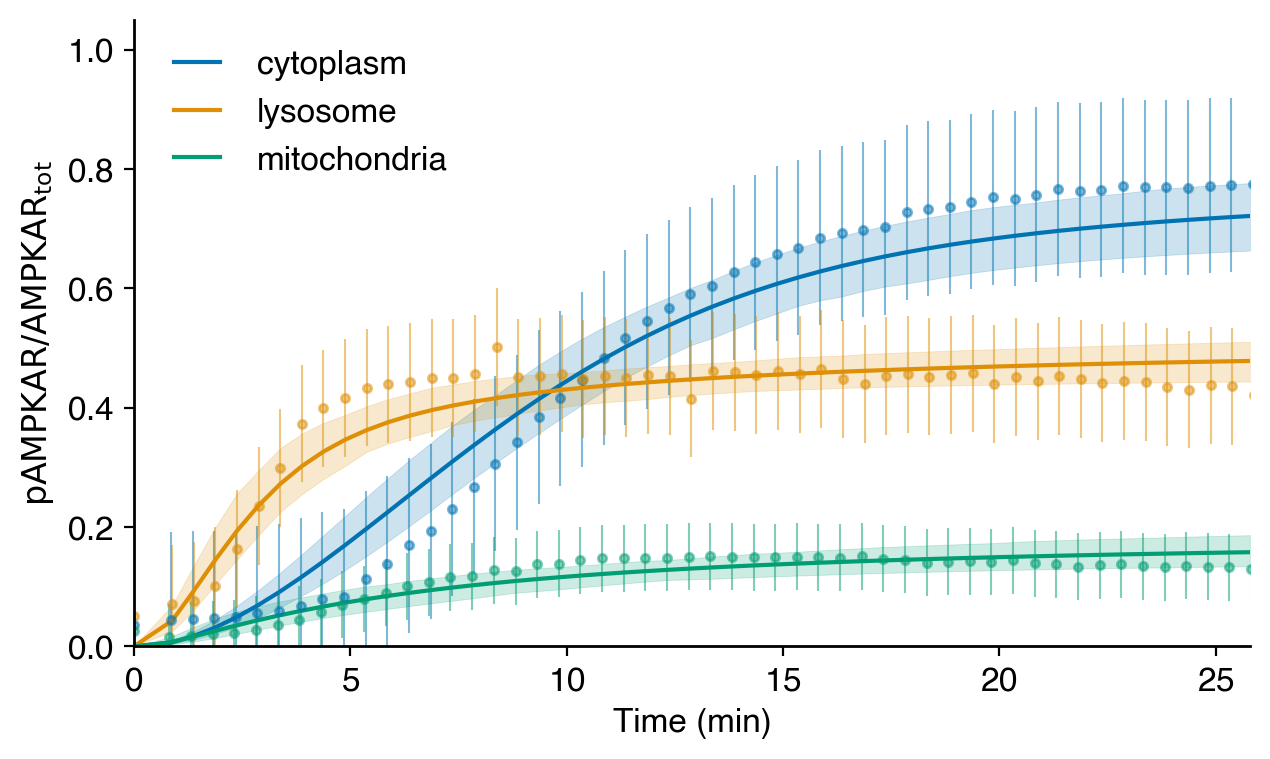

In [187]:
fig, ax = plt.subplots(figsize=(5,3))

ax.errorbar(cyto_times/60, cyto_mean, cyto['std_constant']*np.ones_like(cyto_mean), 
            alpha=0.5, linewidth=0.75, fmt='.', color=cols[0])
ax.errorbar(lyso_times/60, lyso_mean, lyso['std_constant']*np.ones_like(lyso_mean), 
            alpha=0.5, linewidth=0.75, fmt='.', color=cols[1])
ax.errorbar(mito_times/60, mito_mean, mito['std_constant']*np.ones_like(mito_mean), 
            alpha=0.5, linewidth=0.75, fmt='.', color=cols[2])

plot_pred_check(cyto_post_sols, cyto_times/60, ax, 1.0, cols[0])
plot_pred_check(lyso_post_sols, lyso_times/60, ax, 1.0, cols[1])
plot_pred_check(mito_post_sols, mito_times/60, ax, 1.0, cols[2])
ax.legend()
ax.set_xlabel('Time (min)')
ax.set_ylabel(r'$pAMPKAR/AMPKAR_{tot}$')
ax.set_ylim([0.0, 1.05])
ax.set_xlim([0.0, 25.8]) # upper is the shortest time which mito_times[-1]/60
ax.plot([], [], color=cols[0], label='cytoplasm')
ax.plot([], [], color=cols[1], label='lysosome')
ax.plot([], [], color=cols[2], label='mitochondria')
ax.legend(loc='upper left')
set_size(5,3,ax=ax)
fig.savefig('../../../figures/MA_double_mech/pAMPKAR_posterior.pdf')

array([0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589, 0.14644589, 0.14644589,
       0.14644589, 0.14644589, 0.14644589])